In [ ]:
#part a)
import cv2 as cv
import numpy as np

N = 5   # number of points

# Global variables
n = 0
p1 = np.zeros((N, 2), dtype=np.float32)
p2 = np.zeros((N, 2), dtype=np.float32)

# Mouse callback function
def draw_circle(event, x, y, flags, param):
    global n
    points = param[0]
    image = param[1]

    if event == cv.EVENT_LBUTTONDOWN and n < N:
        cv.circle(image, (x, y), 5, (255, 0, 0), -1)
        points[n] = (x, y)
        print(f"Point {n+1}: ({x}, {y})")
        n += 1

# Load images (reduced size for easier clicking)
im1 = cv.imread('c1.jpg', cv.IMREAD_REDUCED_COLOR_4)
im2 = cv.imread('c2.jpg', cv.IMREAD_REDUCED_COLOR_4)

im1copy = im1.copy()
im2copy = im2.copy()

# ---- Select points from Image 1 ----
n = 0
cv.namedWindow("Image 1")
param = [p1, im1copy]
cv.setMouseCallback("Image 1", draw_circle, param)

while True:
    cv.imshow("Image 1", im1copy)
    if n == N:
        break
    if cv.waitKey(20) & 0xFF == 27:
        break

cv.destroyWindow("Image 1")

# ---- Select points from Image 2 ----
n = 0
cv.namedWindow("Image 2")
param = [p2, im2copy]
cv.setMouseCallback("Image 2", draw_circle, param)

while True:
    cv.imshow("Image 2", im2copy)
    if n == N:
        break
    if cv.waitKey(20) & 0xFF == 27:
        break

cv.destroyWindow("Image 2")

print("Points Image 1:\n", p1)
print("Points Image 2:\n", p2)

# Compute Homography
H, _ = cv.findHomography(p1, p2)

# Warp Image
height, width = im2.shape[:2]
warped = cv.warpPerspective(im1, H, (width, height))

# ---- Display Results ----
cv.imshow("Original Image 1", im1)
cv.imshow("Reference Image 2", im2)
cv.imshow("Warped Image", warped)

cv.waitKey(0)
cv.destroyAllWindows()

In [ ]:
#part b)
import cv2 as cv
import numpy as np

# Convert both images to same type
warped_uint8 = cv.convertScaleAbs(warped)
im2_uint8 = cv.convertScaleAbs(im2)

# Compute absolute difference
difference = cv.absdiff(warped_uint8, im2_uint8)

# Display results
cv.imshow("Warped Image", warped_uint8)
cv.imshow("Reference Image", im2_uint8)
cv.imshow("Difference Image", difference)

cv.waitKey(0)
cv.destroyAllWindows()

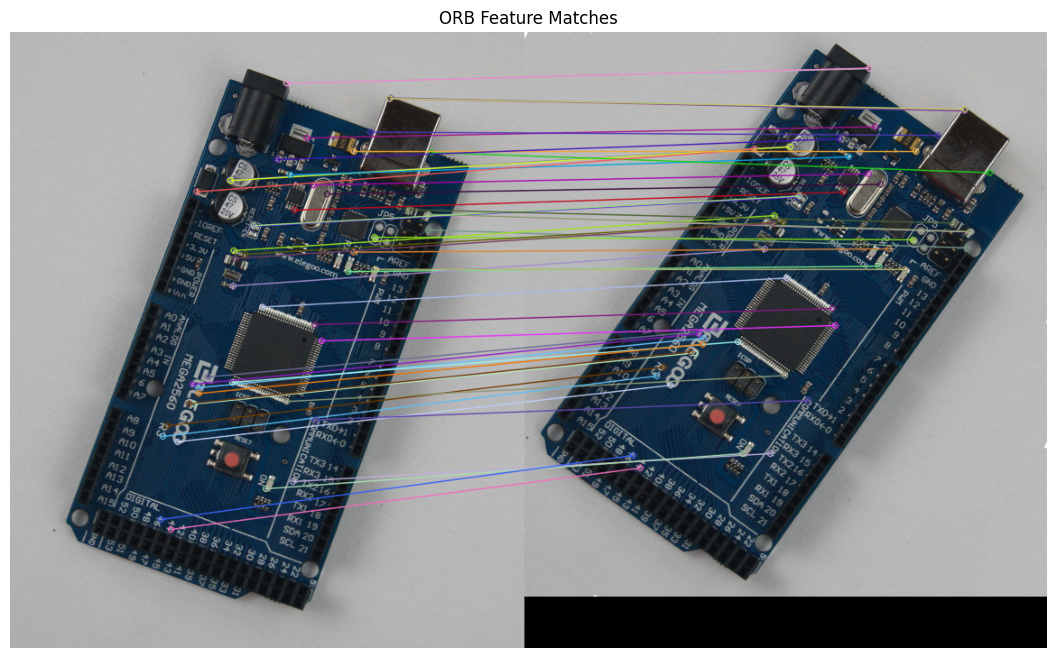

In [3]:
#part c
import cv2 as cv
import matplotlib.pyplot as plt

# Load images
img1 = cv.imread("c1.jpg", cv.IMREAD_REDUCED_COLOR_4)
img2 = cv.imread("c2.jpg", cv.IMREAD_REDUCED_COLOR_4)

# Convert to grayscale
gray1 = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)

# Create ORB detector
orb = cv.ORB_create(nfeatures=1000)

# Detect keypoints and compute descriptors
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# Match descriptors using Brute Force Matcher
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

# Sort matches by distance
matches = sorted(matches, key=lambda x: x.distance)

# Draw best matches
matched_img = cv.drawMatches(
    img1, kp1,
    img2, kp2,
    matches[:50],
    None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Display output
plt.figure(figsize=(15, 8))
plt.imshow(cv.cvtColor(matched_img, cv.COLOR_BGR2RGB))
plt.title("ORB Feature Matches")
plt.axis("off")
plt.show()

Point 1: (244, 54)
Point 2: (510, 149)
Point 3: (57, 542)
Point 4: (332, 596)
Point 1: (16, 444)
Point 2: (266, 566)
Point 3: (322, 18)
Point 4: (553, 182)
Points Image 1:
 [[244.  54.]
 [510. 149.]
 [ 57. 542.]
 [332. 596.]]
Points Image 2:
 [[ 16. 444.]
 [266. 566.]
 [322.  18.]
 [553. 182.]]


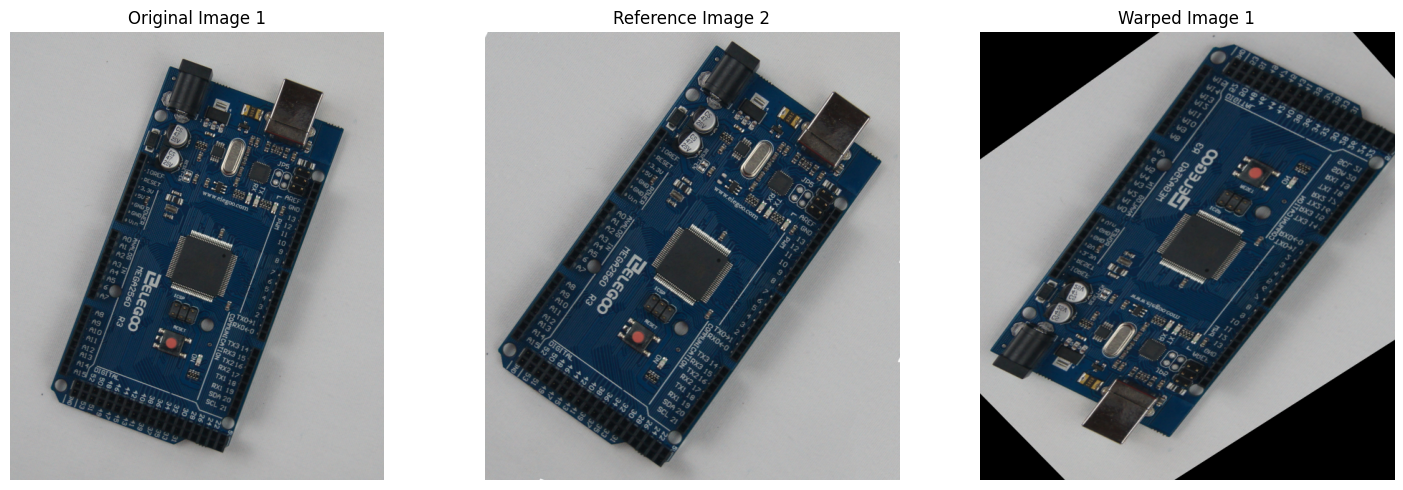

In [3]:
#part a - extra
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Number of points (use 4 corners)
N = 4

# Global variables
n = 0
p1 = np.zeros((N, 2), dtype=np.float32)
p2 = np.zeros((N, 2), dtype=np.float32)

# Mouse callback
def draw_circle(event, x, y, flags, param):
    global n
    points = param[0]
    image = param[1]

    if event == cv.EVENT_LBUTTONDOWN and n < N:
        cv.circle(image, (x, y), 5, (255, 0, 0), -1)
        points[n] = (x, y)
        print(f"Point {n+1}: ({x}, {y})")
        n += 1

# Load images (resize for easy clicking)
im1 = cv.imread('c1.jpg', cv.IMREAD_REDUCED_COLOR_4)
im2 = cv.imread('c2.jpg', cv.IMREAD_REDUCED_COLOR_4)

im1copy = im1.copy()
im2copy = im2.copy()

# ---- Select points from Image 1 ----
n = 0
cv.namedWindow("Image 1")
cv.setMouseCallback("Image 1", draw_circle, [p1, im1copy])

while True:
    cv.imshow("Image 1", im1copy)
    if n == N:
        break
    if cv.waitKey(20) & 0xFF == 27:
        break

cv.destroyWindow("Image 1")

# ---- Select points from Image 2 ----
n = 0
cv.namedWindow("Image 2")
cv.setMouseCallback("Image 2", draw_circle, [p2, im2copy])

while True:
    cv.imshow("Image 2", im2copy)
    if n == N:
        break
    if cv.waitKey(20) & 0xFF == 27:
        break

cv.destroyWindow("Image 2")

# Print points (for checking)
print("Points Image 1:\n", p1)
print("Points Image 2:\n", p2)

# ---- Compute Homography ----
H, _ = cv.findHomography(p1, p2, 0)

# ---- Warp Image ----
height, width = im2.shape[:2]
warped = cv.warpPerspective(im1, H, (width, height))

# ---- Convert to RGB for matplotlib ----
im1_rgb = cv.cvtColor(im1, cv.COLOR_BGR2RGB)
im2_rgb = cv.cvtColor(im2, cv.COLOR_BGR2RGB)
warped_rgb = cv.cvtColor(warped, cv.COLOR_BGR2RGB)

# ---- Display results (LIKE YOUR REQUIRED OUTPUT) ----
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(im1_rgb)
plt.title("Original Image 1")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(im2_rgb)
plt.title("Reference Image 2")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(warped_rgb)
plt.title("Warped Image 1")
plt.axis("off")

plt.tight_layout()
plt.show()